# AWS Bedrock: Amazon Nova 2 Lite Inference using LangChain & LangGraph

This notebook demonstrates how to invoke the **Amazon Nova 2 Lite v1.0** model using AWS Bedrock, integrated via the **LangChain** and **LangGraph** frameworks.

### Prerequisites
Make sure you have configured your AWS credentials (`aws configure`) or have set your AWS environment variables before running this notebook. The IAM role or user must have permission to invoke models in Amazon Bedrock (`bedrock:InvokeModel`).

## Step 1: Install Required Libraries

First, install the latest versions of `langchain-aws`, `langgraph`, and `boto3`.

In [16]:
# Uncomment and run to install dependencies if needed
# !pip install -U langchain-aws langgraph boto3

## Step 2: Set up Imports & Configure Model

We use the recommended `ChatBedrockConverse` class which leverages the Bedrock Converse API for structured tool usage and chat capability.

> [!NOTE]
> We use the cross-region inference profile ID `us.amazon.nova-2-lite-v1:0` (with the `us.` prefix) instead of the raw foundation model ID `amazon.nova-2-lite-v1:0`. Under AWS Bedrock, on-demand throughput requests for newer models like Amazon Nova require using inference profiles rather than base model IDs.

In [17]:
from typing import TypedDict, Annotated
from langchain_aws import ChatBedrockConverse
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Use the cross-region inference profile ID for Amazon Nova 2 Lite in US regions
MODEL_ID = "minimax.minimax-m2.5"
AWS_REGION = "us-east-1"  # Replace with the AWS region where Nova is enabled (e.g. us-east-1 or us-west-2)

print(f"Configured model: {MODEL_ID} in region {AWS_REGION}")

Configured model: minimax.minimax-m2.5 in region us-east-1


## Step 3: Define LangGraph Agent State & Node

We will build a simple single-node graph. 
1. The **State** is a TypedDict tracking our chat messages history.
2. The **Node** is a Python function that invokes the Nova model using `ChatBedrockConverse` and returns the model output to update the message list.

In [18]:
# 1. Define graph state
class AgentState(TypedDict):
    # Annotated with add_messages so new messages are appended to the list rather than overwriting it
    messages: Annotated[list[BaseMessage], add_messages]

# 2. Define node function to invoke Bedrock model
def call_nova_model(state: AgentState):
    llm = ChatBedrockConverse(
        model=MODEL_ID,
        temperature=0.7,
        region_name=AWS_REGION
    )
    # Invoke LLM with current message state
    response = llm.invoke(state["messages"])
    # Return message update dict
    return {"messages": [response]}

## Step 4: Build and Compile the Graph

Connect the node in a simple graph flow: START -> call_nova_model -> END.

In [19]:
# Initialize the graph builder
builder = StateGraph(AgentState)

# Add model node
builder.add_node("ai", call_nova_model)

# Define edges
builder.add_edge(START, "ai")
builder.add_edge("ai", END)

# Compile the graph
graph = builder.compile()
print("Graph compiled successfully.")

Graph compiled successfully.


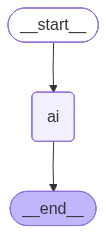

In [20]:
graph

## Step 5: Execute Simple Inference

Now we will define a prompt, trigger the graph execution via `.invoke()`, and inspect the output.

In [23]:
# Prepare input query
prompt = "Explain what makes the Amazon Nova model suite unique in Bedrock in a single paragraph."
input_state = {"messages": [HumanMessage(content=prompt)]}

print(f"Sending prompt: {prompt}\n")

try:
    # Invoke the compiled LangGraph workflow
    output_state = graph.invoke(input_state)
    
    # Extract and display result
    final_response = output_state["messages"][-1].content
    print("--- Nova Response ---")
    print(final_response[0]['reasoning_content']['text'])
except Exception as e:
    print(f"An error occurred during inference. Ensure you have valid credentials and model access.\nDetails: {e}")

Sending prompt: Explain what makes the Amazon Nova model suite unique in Bedrock in a single paragraph.

--- Nova Response ---
The user asks: "Explain what makes the Amazon Nova model suite unique in Bedrock in a single paragraph."

We need to respond with a concise paragraph explaining the uniqueness of Amazon Nova model suite in Bedrock. The user likely expects something about Amazon Nova being a family of foundation models available in Amazon Bedrock, perhaps with multimodal capabilities, high performance, cost-effective, fine-tuning, custom model training, security, privacy, integration with AWS services, and being fully managed. But we need to give a single paragraph. We need to be concise but cover key points: It's a suite of models (Nova) that includes different model sizes (like micro, lite, pro, etc.) optimized for different tasks, multimodal (text, image, video), low latency, high throughput, cost efficiency, integrated with Bedrock's features like fine-tuning, guardrails, ag

In [22]:
import boto3
sts = boto3.client('sts')
identity = sts.get_caller_identity()

print("Account ID:", identity['Account'])
print("Caller ARN:", identity['Arn'])

Account ID: 869935080204
Caller ARN: arn:aws:iam::869935080204:user/sachinmishra
